In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Uploading the CSV file

Since the file `2020_al_data_kaggle_upload_new_old_syllabi.csv` was not found, please use the following code to upload it from your local machine. This will open a file selection dialog.

In [24]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving 2020_al_data_kaggle_upload_new_old_syllabi.csv to 2020_al_data_kaggle_upload_new_old_syllabi.csv
User uploaded file "2020_al_data_kaggle_upload_new_old_syllabi.csv" with length 42190315 bytes


## ETL: Extraction Step

This step involves loading the raw data from its source into a pandas DataFrame. In this case, we're reading the `2020_al_data_kaggle_upload_new_old_syllabi.csv` file, which should now be available in the Colab environment after the upload.

In [25]:
# Read the uploaded CSV file into a pandas DataFrame
df_extracted = pd.read_csv('2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Extracted Successfully ---")
display(df_extracted.head()) # Display the first 5 rows of the extracted data

--- Data Extracted Successfully ---


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


## ETL: Transformation Step

This step involves cleaning and preparing the data for analysis. Here, we'll remove rows with null values in the 'Zscore' column to ensure data quality for subsequent calculations, and convert the 'Zscore' column to a numeric type.

In [26]:
# Remove rows with null values in the 'Zscore' column
initial_rows = df_extracted.shape[0]
df_extracted.dropna(subset=['Zscore'], inplace=True)
cleaned_rows = df_extracted.shape[0]

print(f"Removed {initial_rows - cleaned_rows} rows with null 'Zscore' values.")
print("DataFrame after cleaning 'Zscore' nulls:")
display(df_extracted.head())

Removed 3 rows with null 'Zscore' values.
DataFrame after cleaning 'Zscore' nulls:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [27]:
# Convert 'Zscore' column to numeric type
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')

print("Data type of 'Zscore' column after conversion:")
print(df_extracted['Zscore'].dtype)
print("First 5 rows of df_extracted with updated 'Zscore' type:")
display(df_extracted.head())

Data type of 'Zscore' column after conversion:
float64
First 5 rows of df_extracted with updated 'Zscore' type:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


## Result after Transformation

In [28]:
print(f"DataFrame shape after transformation: {df_extracted.shape[0]} rows, {df_extracted.shape[1]} columns")

DataFrame shape after transformation: 337550 rows, 19 columns


## ETL: Extraction Step

In [29]:
# Read the uploaded CSV file into a pandas DataFrame
df_extracted = pd.read_csv('2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Extracted Successfully ---")
display(df_extracted.head()) # Display the first 5 rows of the extracted data

--- Data Extracted Successfully ---


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


## ETL: Transformation Step

In [30]:
# Remove rows with null values in the 'Zscore' column
initial_rows = df_extracted.shape[0]
df_extracted.dropna(subset=['Zscore'], inplace=True)
cleaned_rows = df_extracted.shape[0]

print(f"Removed {initial_rows - cleaned_rows} rows with null 'Zscore' values.")
print("DataFrame after cleaning 'Zscore' nulls:")
display(df_extracted.head())

Removed 3 rows with null 'Zscore' values.
DataFrame after cleaning 'Zscore' nulls:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [31]:
# Convert 'Zscore' column to numeric type
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')

print("Data type of 'Zscore' column after conversion:")
print(df_extracted['Zscore'].dtype)
print("First 5 rows of df_extracted with updated 'Zscore' type:")
display(df_extracted.head())

Data type of 'Zscore' column after conversion:
float64
First 5 rows of df_extracted with updated 'Zscore' type:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


## Result after Transformation

In [32]:
print(f"DataFrame shape after transformation: {df_extracted.shape[0]} rows, {df_extracted.shape[1]} columns")

DataFrame shape after transformation: 337550 rows, 19 columns


## Re-running ETL: Extraction Step

In [33]:
# Read the uploaded CSV file into a pandas DataFrame
df_extracted = pd.read_csv('2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Extracted Successfully ---")
display(df_extracted.head()) # Display the first 5 rows of the extracted data

--- Data Extracted Successfully ---


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


## Re-running ETL: Transformation Step

In [34]:
# Remove rows with null values in the 'Zscore' column
initial_rows = df_extracted.shape[0]
df_extracted.dropna(subset=['Zscore'], inplace=True)
cleaned_rows = df_extracted.shape[0]

print(f"Removed {initial_rows - cleaned_rows} rows with null 'Zscore' values.")
print("DataFrame after cleaning 'Zscore' nulls:")
display(df_extracted.head())

Removed 3 rows with null 'Zscore' values.
DataFrame after cleaning 'Zscore' nulls:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [35]:
# Convert 'Zscore' column to numeric type
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')

print("Data type of 'Zscore' column after conversion:")
print(df_extracted['Zscore'].dtype)
print("First 5 rows of df_extracted with updated 'Zscore' type:")
display(df_extracted.head())

Data type of 'Zscore' column after conversion:
float64
First 5 rows of df_extracted with updated 'Zscore' type:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


## Data after Transformation

In [36]:
print(f"DataFrame shape after transformation: {df_extracted.shape[0]} rows, {df_extracted.shape[1]} columns")

DataFrame shape after transformation: 337550 rows, 19 columns


In [41]:
print("\n--- Available Columns ---")
print(df_extracted.columns.tolist())


--- Available Columns ---
['index', 'stream', 'Zscore', 'district_rank', 'island_rank', 'al_year', 'sub1', 'sub1_r', 'sub2', 'sub2_r', 'sub3', 'sub3_r', 'cgt_r', 'ge_r', 'syllabus', 'birth_day', 'birth_month', 'birth_year', 'gender']



--- Average Zscore by Stream ---
                   stream    Zscore
0                       - -0.559873
1                    ARTS  0.471465
2      BIOLOGICAL SCIENCE  0.605590
3   BIOSYSTEMS TECHNOLOGY  0.487498
4                COMMERCE  0.496741
5  ENGINEERING TECHNOLOGY  0.463578
6                     NON  0.466190
7        PHYSICAL SCIENCE  0.638012


/tmp/ipykernel_1156/202105878.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stream', y='Zscore', data=stream_zscore_avg, palette='viridis')


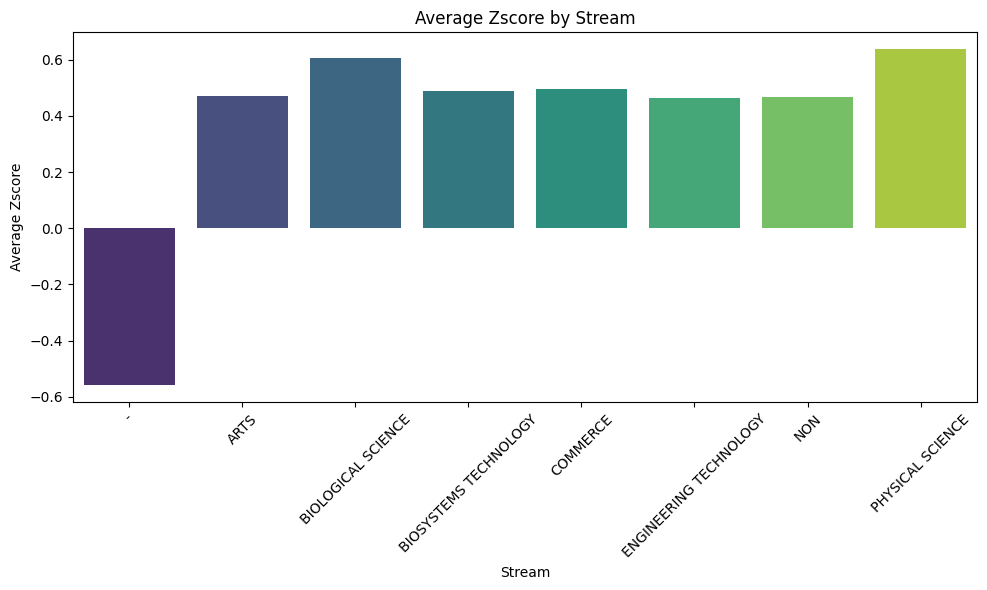

In [42]:
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')
stream_zscore_avg = df_extracted.groupby('stream')['Zscore'].mean().reset_index()
print("\n--- Average Zscore by Stream ---")
print(stream_zscore_avg)

# Optional: Visualize the average Zscore by stream
plt.figure(figsize=(10, 6))
sns.barplot(x='stream', y='Zscore', data=stream_zscore_avg, palette='viridis')
plt.title('Average Zscore by Stream')
plt.xlabel('Stream')
plt.ylabel('Average Zscore')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
print("\n--- Summary Statistics for Zscore ---")
print(df_extracted['Zscore'].describe())


--- Summary Statistics for Zscore ---
count    232304.000000
mean          0.305389
std           0.763854
min          -1.938300
25%          -0.300200
50%           0.221700
75%           0.852800
max           3.558300
Name: Zscore, dtype: float64


## ETL: Extraction Step

This step involves loading the raw data from its source into a pandas DataFrame. In this case, we're reading the `2020_al_data_kaggle_upload_new_old_syllabi.csv` file.

In [45]:
# Read the uploaded CSV file into a pandas DataFrame
df_extracted = pd.read_csv('2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Extracted Successfully ---")
print(df_extracted.head()) # Display the first 5 rows of the extracted data

--- Data Extracted Successfully ---
   index    stream   Zscore district_rank  island_rank  al_year  \
0      0      ARTS   -0.355    4336 (NEW)  64994 (NEW)     2020   
1      1      ARTS  -0.2648    4154 (NEW)  62338 (NEW)     2020   
2      2  COMMERCE   -0.476    6910 (NEW)  37307 (NEW)     2020   
3      3  COMMERCE  -0.1012    5678 (NEW)  30449 (NEW)     2020   
4      4  COMMERCE   0.6014    3269 (NEW)  17010 (NEW)     2020   

                sub1 sub1_r               sub2 sub2_r        sub3 sub3_r  \
0  POLITICAL SCIENCE      S  DANCING(BHARATHA)      C       TAMIL      S   
1  POLITICAL SCIENCE      S     CARNATIC MUSIC      C       TAMIL      C   
2          ECONOMICS      S   BUSINESS STUDIES      S  ACCOUNTING      S   
3          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      S   
4          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      B   

  cgt_r ge_r syllabus birth_day birth_month birth_year  gender  
0    56    S      new        31        

## ETL: Transformation Step

This step involves cleaning and preparing the data for analysis. Here, we'll remove rows with null values in the 'Zscore' column, as requested, to ensure data quality for subsequent calculations.

In [46]:
# Remove rows with null values in the 'Zscore' column
initial_rows = df_extracted.shape[0]
df_extracted.dropna(subset=['Zscore'], inplace=True)
cleaned_rows = df_extracted.shape[0]

print(f"Removed {initial_rows - cleaned_rows} rows with null 'Zscore' values.")
print("DataFrame after cleaning 'Zscore' nulls:")
display(df_extracted.head())

Removed 3 rows with null 'Zscore' values.
DataFrame after cleaning 'Zscore' nulls:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [47]:
# Convert 'Zscore' column to numeric type
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')

print("Data type of 'Zscore' column after conversion:")
print(df_extracted['Zscore'].dtype)
print("First 5 rows of df_extracted with updated 'Zscore' type:")
display(df_extracted.head())

Data type of 'Zscore' column after conversion:
float64
First 5 rows of df_extracted with updated 'Zscore' type:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [48]:
print(f"DataFrame shape after transformation: {df_extracted.shape[0]} rows, {df_extracted.shape[1]} columns")

DataFrame shape after transformation: 337550 rows, 19 columns


In [49]:
# Read the uploaded CSV file into a pandas DataFrame
df_extracted = pd.read_csv('2020_al_data_kaggle_upload_new_old_syllabi.csv')

print("--- Data Extracted Successfully ---")
print(df_extracted.head()) # Display the first 5 rows of the extracted data

--- Data Extracted Successfully ---
   index    stream   Zscore district_rank  island_rank  al_year  \
0      0      ARTS   -0.355    4336 (NEW)  64994 (NEW)     2020   
1      1      ARTS  -0.2648    4154 (NEW)  62338 (NEW)     2020   
2      2  COMMERCE   -0.476    6910 (NEW)  37307 (NEW)     2020   
3      3  COMMERCE  -0.1012    5678 (NEW)  30449 (NEW)     2020   
4      4  COMMERCE   0.6014    3269 (NEW)  17010 (NEW)     2020   

                sub1 sub1_r               sub2 sub2_r        sub3 sub3_r  \
0  POLITICAL SCIENCE      S  DANCING(BHARATHA)      C       TAMIL      S   
1  POLITICAL SCIENCE      S     CARNATIC MUSIC      C       TAMIL      C   
2          ECONOMICS      S   BUSINESS STUDIES      S  ACCOUNTING      S   
3          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      S   
4          ECONOMICS      C   BUSINESS STUDIES      C  ACCOUNTING      B   

  cgt_r ge_r syllabus birth_day birth_month birth_year  gender  
0    56    S      new        31        

## ETL: Transformation Step

This step involves cleaning and preparing the data for analysis. Here, we'll remove rows with null values in the 'Zscore' column, as requested, to ensure data quality for subsequent calculations.

In [50]:
# Remove rows with null values in the 'Zscore' column
initial_rows = df_extracted.shape[0]
df_extracted.dropna(subset=['Zscore'], inplace=True)
cleaned_rows = df_extracted.shape[0]

print(f"Removed {initial_rows - cleaned_rows} rows with null 'Zscore' values.")
print("DataFrame after cleaning 'Zscore' nulls:")
display(df_extracted.head())

Removed 3 rows with null 'Zscore' values.
DataFrame after cleaning 'Zscore' nulls:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [51]:
# Convert 'Zscore' column to numeric type
df_extracted['Zscore'] = pd.to_numeric(df_extracted['Zscore'], errors='coerce')

print("Data type of 'Zscore' column after conversion:")
print(df_extracted['Zscore'].dtype)
print("First 5 rows of df_extracted with updated 'Zscore' type:")
display(df_extracted.head())

Data type of 'Zscore' column after conversion:
float64
First 5 rows of df_extracted with updated 'Zscore' type:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female


In [52]:
print(f"DataFrame shape after transformation: {df_extracted.shape[0]} rows, {df_extracted.shape[1]} columns")

DataFrame shape after transformation: 337550 rows, 19 columns


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# ============================================================
# 2. UPLOAD CSV
# ============================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)


# ============================================================
# 3. EXTRACTION
# ============================================================

df = pd.read_csv(filename)

print("Original Dataset Shape:")
print(df.shape)

print("\nAvailable Columns:")
print(df.columns.tolist())

display(df.head())


# ============================================================
# 4. TRANSFORMATION / CLEANING
# ============================================================

# Create a copy
df_clean = df.copy()

# Remove completely empty rows
df_clean.dropna(how='all', inplace=True)

# Remove spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Convert Zscore to numeric
if 'Zscore' in df_clean.columns:
    df_clean['Zscore'] = pd.to_numeric(
        df_clean['Zscore'],
        errors='coerce'
    )

# Remove rows where Zscore is missing
df_clean.dropna(subset=['Zscore'], inplace=True)

print("\nDataset after cleaning:")
print(df_clean.shape)

display(df_clean.head())


# ============================================================
# 5. CHECK COLUMN NAMES
# ============================================================

print("\nFinal Columns:")
for i, col in enumerate(df_clean.columns):
    print(i, ":", col)

Saving 2020_al_data_kaggle_upload_new_old_syllabi.csv to 2020_al_data_kaggle_upload_new_old_syllabi.csv
Uploaded file: 2020_al_data_kaggle_upload_new_old_syllabi.csv
Original Dataset Shape:
(337553, 19)

Available Columns:
['index', 'stream', 'Zscore', 'district_rank', 'island_rank', 'al_year', 'sub1', 'sub1_r', 'sub2', 'sub2_r', 'sub3', 'sub3_r', 'cgt_r', 'ge_r', 'syllabus', 'birth_day', 'birth_month', 'birth_year', 'gender']


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female



Dataset after cleaning:
(232304, 19)


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female



Final Columns:
0 : index
1 : stream
2 : Zscore
3 : district_rank
4 : island_rank
5 : al_year
6 : sub1
7 : sub1_r
8 : sub2
9 : sub2_r
10 : sub3
11 : sub3_r
12 : cgt_r
13 : ge_r
14 : syllabus
15 : birth_day
16 : birth_month
17 : birth_year
18 : gender


In [2]:
# ============================================================
# A/L DATASET - FACT & DIMENSION TABLE CREATION
# STAR SCHEMA
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

filename = '2020_al_data_kaggle_upload_new_old_syllabi.csv'

df = pd.read_csv(filename)

print("Original Dataset:")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())


# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

df.columns = df.columns.str.strip()

# Convert Zscore to numeric
df['Zscore'] = pd.to_numeric(
    df['Zscore'],
    errors='coerce'
)

# Convert ranks to numeric
rank_columns = [
    'district_rank',
    'island_rank',
    'sub1_r',
    'sub2_r',
    'sub3_r',
    'cgt_r',
    'ge_r'
]

for col in rank_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

# Remove records without Zscore
df = df.dropna(subset=['Zscore']).copy()

# Reset index
df.reset_index(drop=True, inplace=True)

print("\nAfter Cleaning:")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


# ============================================================
# 3. DIMENSION TABLE - STUDENT
# ============================================================

dim_student = df[
    [
        'index',
        'gender',
        'birth_day',
        'birth_month',
        'birth_year'
    ]
].drop_duplicates().reset_index(drop=True)

# Create surrogate key
dim_student.insert(
    0,
    'student_key',
    range(1, len(dim_student) + 1)
)

print("\n========== DIM STUDENT ==========")
display(dim_student.head())

print("Rows:", len(dim_student))


# ============================================================
# 4. DIMENSION TABLE - STREAM
# ============================================================

dim_stream = df[
    ['stream']
].drop_duplicates().reset_index(drop=True)

dim_stream.insert(
    0,
    'stream_key',
    range(1, len(dim_stream) + 1)
)

print("\n========== DIM STREAM ==========")
display(dim_stream)

print("Rows:", len(dim_stream))


# ============================================================
# 5. DIMENSION TABLE - YEAR
# ============================================================

dim_year = df[
    ['al_year']
].drop_duplicates().reset_index(drop=True)

dim_year.insert(
    0,
    'year_key',
    range(1, len(dim_year) + 1)
)

print("\n========== DIM YEAR ==========")
display(dim_year)

print("Rows:", len(dim_year))


# ============================================================
# 6. DIMENSION TABLE - SYLLABUS
# ============================================================

dim_syllabus = df[
    ['syllabus']
].drop_duplicates().reset_index(drop=True)

dim_syllabus.insert(
    0,
    'syllabus_key',
    range(1, len(dim_syllabus) + 1)
)

print("\n========== DIM SYLLABUS ==========")
display(dim_syllabus)

print("Rows:", len(dim_syllabus))


# ============================================================
# 7. DIMENSION TABLE - SUBJECT
# ============================================================

# Collect all subjects from sub1, sub2 and sub3

subjects_1 = df[['sub1']].rename(
    columns={'sub1': 'subject'}
)

subjects_2 = df[['sub2']].rename(
    columns={'sub2': 'subject'}
)

subjects_3 = df[['sub3']].rename(
    columns={'sub3': 'subject'}
)

dim_subject = pd.concat(
    [subjects_1, subjects_2, subjects_3],
    ignore_index=True
)

# Remove null subjects
dim_subject = dim_subject.dropna(
    subset=['subject']
)

# Remove duplicates
dim_subject = dim_subject.drop_duplicates(
).reset_index(drop=True)

# Create subject key
dim_subject.insert(
    0,
    'subject_key',
    range(1, len(dim_subject) + 1)
)

print("\n========== DIM SUBJECT ==========")
display(dim_subject)

print("Rows:", len(dim_subject))


# ============================================================
# 8. CREATE FOREIGN KEYS
# ============================================================

# Student Key
df = df.merge(
    dim_student[
        ['student_key', 'index']
    ],
    on='index',
    how='left'
)

# Stream Key
df = df.merge(
    dim_stream[
        ['stream_key', 'stream']
    ],
    on='stream',
    how='left'
)

# Year Key
df = df.merge(
    dim_year[
        ['year_key', 'al_year']
    ],
    on='al_year',
    how='left'
)

# Syllabus Key
df = df.merge(
    dim_syllabus[
        ['syllabus_key', 'syllabus']
    ],
    on='syllabus',
    how='left'
)


# ============================================================
# 9. FACT TABLE - RESULT
# ============================================================

fact_result = df[
    [
        'student_key',
        'stream_key',
        'year_key',
        'syllabus_key',

        # Measures / Results
        'Zscore',
        'district_rank',
        'island_rank',

        # Subject results
        'sub1',
        'sub1_r',
        'sub2',
        'sub2_r',
        'sub3',
        'sub3_r',

        # Other results
        'cgt_r',
        'ge_r'
    ]
].copy()

# Create fact table primary key
fact_result.insert(
    0,
    'result_key',
    range(1, len(fact_result) + 1)
)

print("\n========== FACT RESULT ==========")
display(fact_result.head())

print("Rows:", len(fact_result))
print("Columns:", len(fact_result.columns))


# ============================================================
# 10. DISPLAY ALL TABLES
# ============================================================

print("\n\n==============================")
print("STAR SCHEMA TABLES")
print("==============================")

print("\nDIMENSION TABLES")
print("----------------")

print("dim_student :", dim_student.shape)
print("dim_stream  :", dim_stream.shape)
print("dim_year    :", dim_year.shape)
print("dim_subject :", dim_subject.shape)
print("dim_syllabus:", dim_syllabus.shape)

print("\nFACT TABLE")
print("----------------")
print("fact_result :", fact_result.shape)


# ============================================================
# 11. SAVE TABLES AS CSV
# ============================================================

dim_student.to_csv(
    'dim_student.csv',
    index=False
)

dim_stream.to_csv(
    'dim_stream.csv',
    index=False
)

dim_year.to_csv(
    'dim_year.csv',
    index=False
)

dim_subject.to_csv(
    'dim_subject.csv',
    index=False
)

dim_syllabus.to_csv(
    'dim_syllabus.csv',
    index=False
)

fact_result.to_csv(
    'fact_result.csv',
    index=False
)

print("\nAll Fact & Dimension tables saved successfully!")


# ============================================================
# 12. DOWNLOAD TABLES
# ============================================================

from google.colab import files

files.download('dim_student.csv')
files.download('dim_stream.csv')
files.download('dim_year.csv')
files.download('dim_subject.csv')
files.download('dim_syllabus.csv')
files.download('fact_result.csv')

Original Dataset:
Rows    : 337553
Columns : 19


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.355,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,56,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,32,C,new,13,January,2002,female
2,2,COMMERCE,-0.476,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,50,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,34,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,36,S,new,7,August,2000,female



After Cleaning:
Rows    : 232304
Columns : 19

========== DIM STUDENT ==========


,student_key,index,gender,birth_day,birth_month,birth_year
0,1,0,female,31,May,2001
1,2,1,female,13,January,2002
2,3,2,female,16,August,2001
3,4,3,female,16,August,2001
4,5,4,female,7,August,2000


Rows: 232304

========== DIM STREAM ==========


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>